In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings('ignore')


In [93]:
Mentalhealth_data = pd.read_csv(r"C:\Users\jiten\Desktop\ML_project1\Teen_Mental_Health_Dataset.csv")

In [94]:
Mentalhealth_data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


Not depreased = 0
depreased = 1

# Task 1
1) Total number of raw and column    

2) List all features      

3) Identify => Numerical,Categorical and Target Columns

In [95]:
Mentalhealth_data.shape

(1200, 13)

In [96]:
raws , cols = Mentalhealth_data.shape
print(raws)
print(cols)

1200
13


List all featchures

In [97]:
Mentalhealth_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


In [98]:
Mentalhealth_data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [99]:
for col in Mentalhealth_data.columns:
    print(col)

age
gender
daily_social_media_hours
platform_usage
sleep_hours
screen_time_before_sleep
academic_performance
physical_activity
social_interaction_level
stress_level
anxiety_level
addiction_level
depression_label


Numerical Columns


In [100]:
numerical_col = Mentalhealth_data.select_dtypes(include=["number"]).columns
print(numerical_col)

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')


Categorical Columns

In [101]:
categ_column = Mentalhealth_data.select_dtypes(include='object').columns
categ_column

Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='str')

# 2) Data Cleaning

Missing Value


In [102]:
Mentalhealth_data.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Check Duplicate record


In [103]:
Mentalhealth_data.columns.duplicated().sum()

np.int64(0)

Handle inconsistent value

In [104]:
for i in categ_column :
    unique_value = Mentalhealth_data[i].unique()
    print(unique_value)
    

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str
<ArrowStringArray>
['Instagram', 'TikTok', 'Both']
Length: 3, dtype: str
<ArrowStringArray>
['low', 'high', 'medium']
Length: 3, dtype: str


In [105]:
Mentalhealth_data['platform_usage'].value_counts()

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

In [106]:
Mentalhealth_data['social_interaction_level'].value_counts()

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

In [107]:
Mentalhealth_data['gender'].value_counts()

gender
male      615
female    585
Name: count, dtype: int64

Checkung Outliers using boxplot

<function matplotlib.pyplot.show(close=None, block=None)>

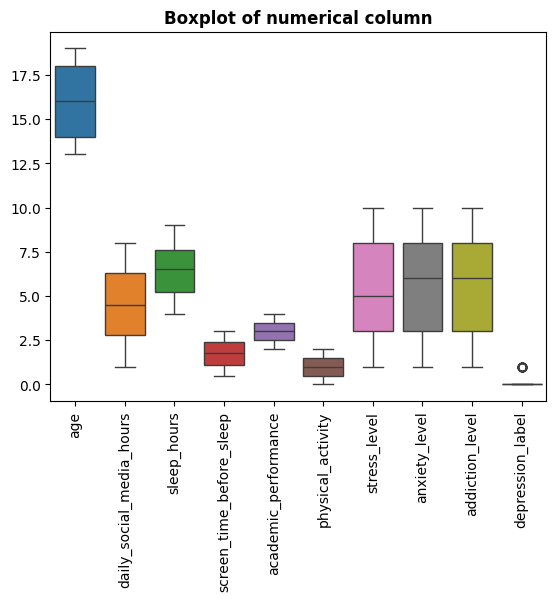

In [108]:
#column_for_boxplot = Mentalhealth_data.select_dtypes(include='number').columns

plt.Figure(figsize=(12,6))
sb.boxplot(data=Mentalhealth_data.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title("Boxplot of numerical column", fontweight='bold')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

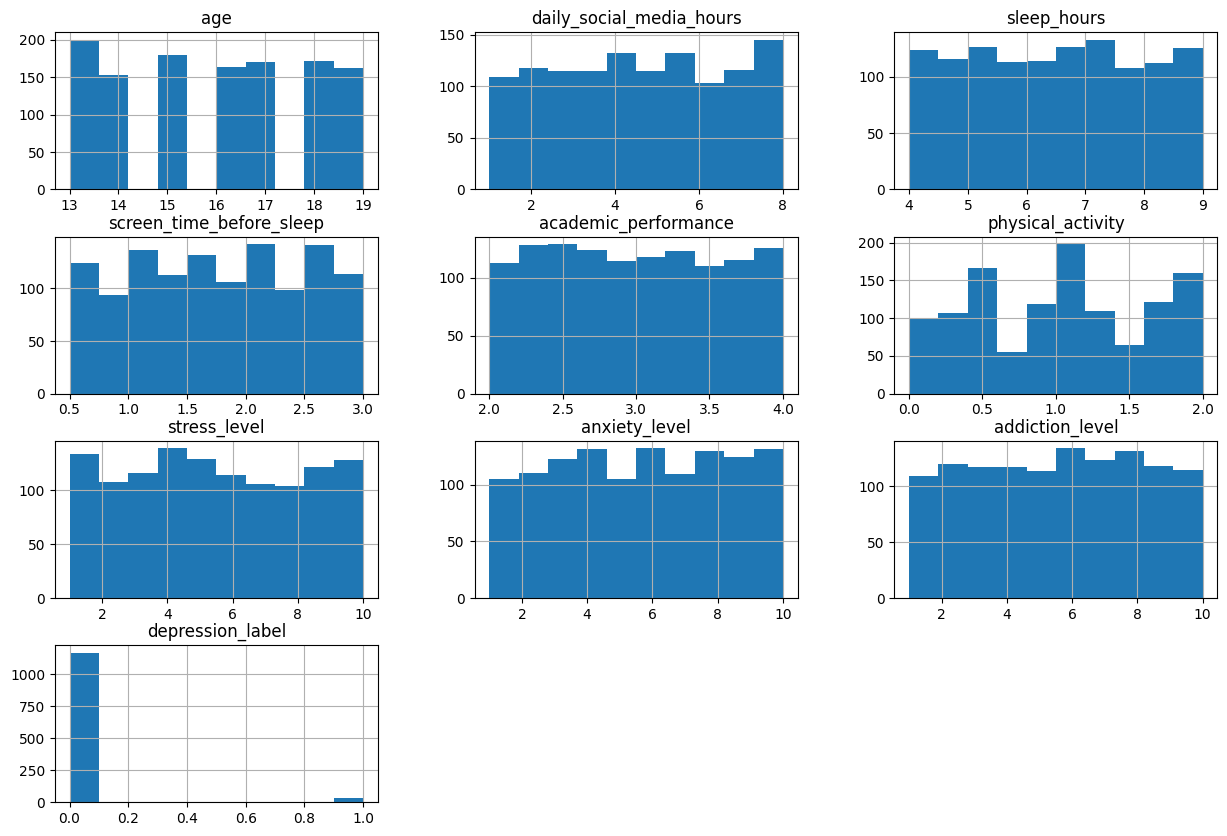

In [109]:
Mentalhealth_data[numerical_col].hist(figsize=(15,10))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

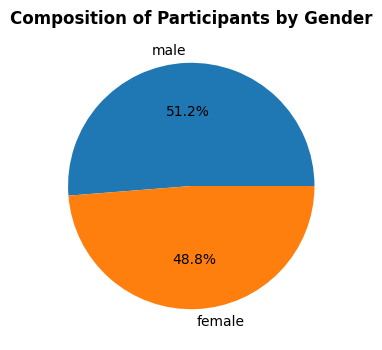

In [110]:
counts = Mentalhealth_data['gender'].replace({
    1: 'Male',
    0: 'Female'
}).value_counts()
plt.figure(figsize=(4,4))
plt.pie(counts,labels=counts.index,autopct='%1.1f%%')
plt.title('Composition of Participants by Gender', fontweight="bold")
plt.show

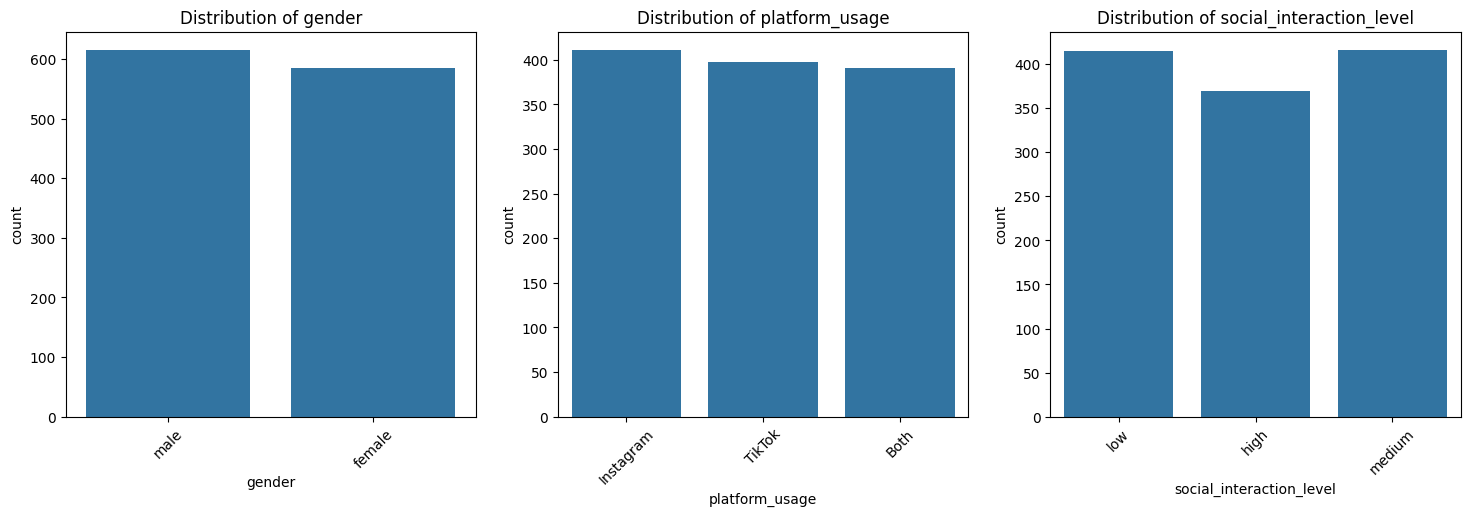

In [111]:
n_cols = 3
n_rows = (len(categ_column) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows,n_cols,figsize=(18,5*n_rows))
axes = axes.flatten()

for i,col in enumerate(categ_column):
    sb.countplot(x=Mentalhealth_data[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x',rotation=45)
    
for j in range(i + 1 , len(axes)):
    fig.delaxes(axes[j])
    
plt.show()
    

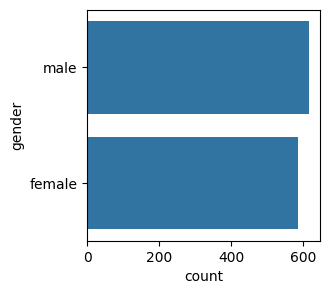

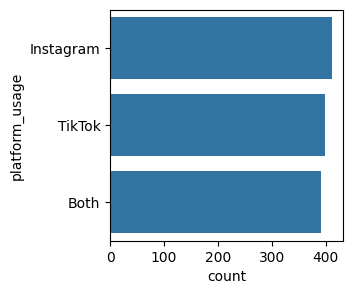

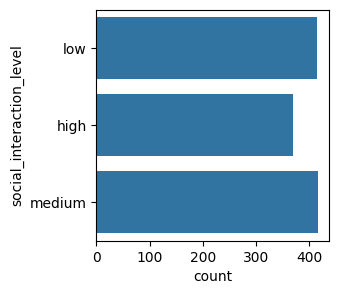

In [112]:
categ_column = Mentalhealth_data.select_dtypes(include=['object']).columns
for i in categ_column:
    plt.figure(figsize=(3,3))
    sb.countplot(Mentalhealth_data[i])
    plt.show()

# Bivariate Analyis

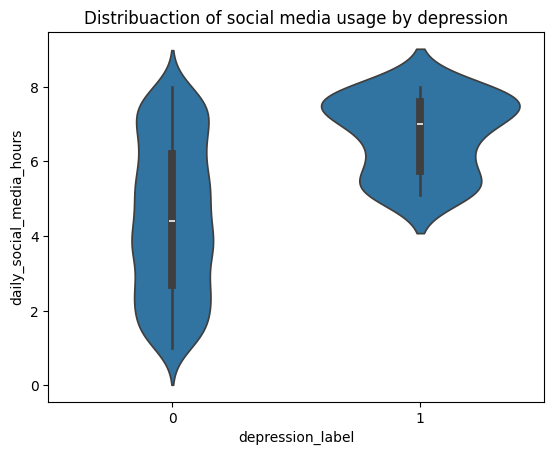

In [113]:
plt.Figure(figsize=(6,4))
sb.violinplot(x='depression_label',y='daily_social_media_hours',data=Mentalhealth_data)
plt.title('Distribuaction of social media usage by depression')
plt.show()

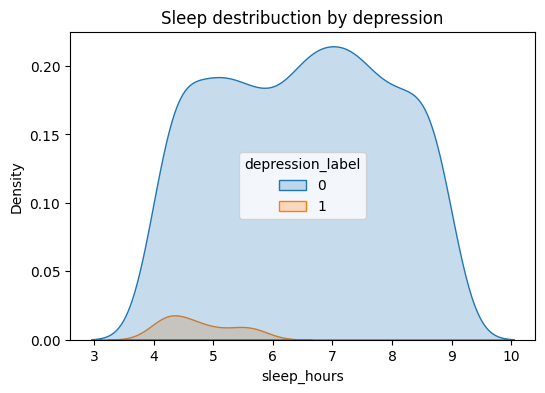

In [114]:
plt.figure(figsize=(6,4))
sb.kdeplot(data=Mentalhealth_data,x='sleep_hours',hue='depression_label',fill=True)
plt.title('Sleep destribuction by depression')
plt.show()

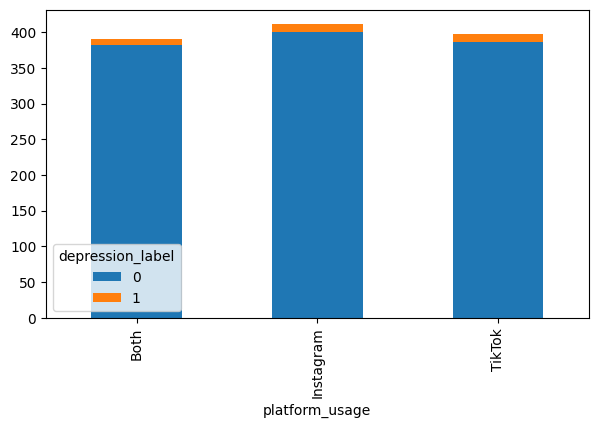

In [115]:
ct = pd.crosstab(Mentalhealth_data['platform_usage'],Mentalhealth_data['depression_label'])

ax = ct.plot(
    kind='bar',
    stacked= True,
    figsize=(7,4)
)

# Multivariate Analysis

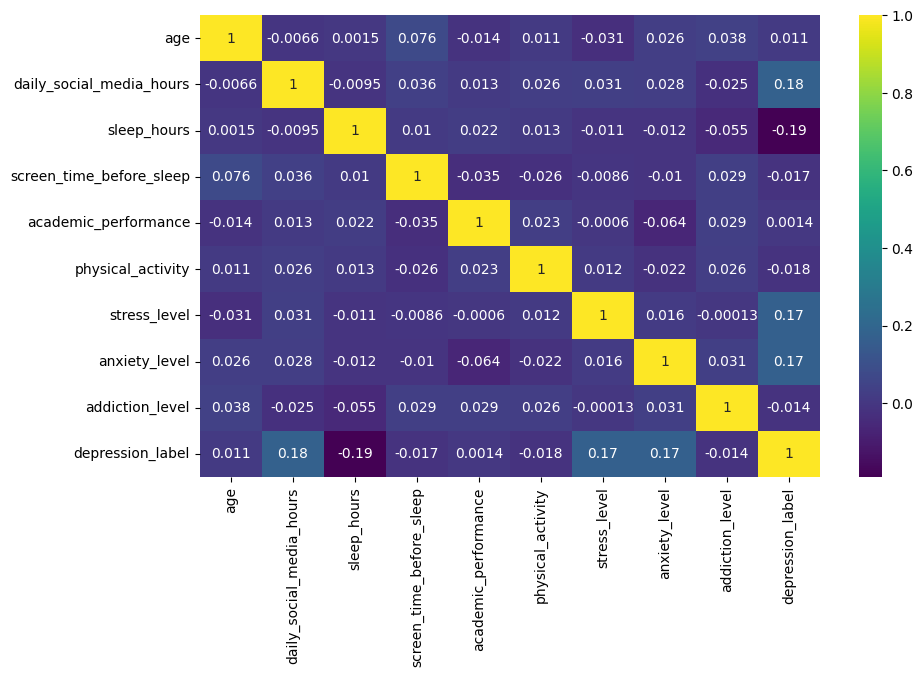

In [116]:
plt.figure(figsize=(10,6))
sb.heatmap(Mentalhealth_data.corr(numeric_only=True),annot=True,cmap='viridis')
plt.show()

Corelaction 

In [117]:
corr = Mentalhealth_data.corr(numeric_only=True)

corr['depression_label'].sort_values(ascending=False)

depression_label            1.000000
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
Name: depression_label, dtype: float64

# Machine learning model building

Feature encoding

In [118]:
categ_column

Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='str')

Label Encoding

In [119]:
from sklearn.preprocessing import LabelEncoder

for i in categ_column :
    Mentalhealth_data[i] = LabelEncoder().fit_transform(Mentalhealth_data[i])

In [120]:
Mentalhealth_data.head(4)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0


# Feature Selection

In [121]:
x = Mentalhealth_data.iloc[:,:-1]
y = Mentalhealth_data.iloc[:,-1]


In [122]:
x

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,0,6.8,1,6.6,2.0,2.76,1.0,1,3,4,4
1196,16,1,2.3,0,8.0,1.9,2.12,0.4,0,7,4,4
1197,14,0,1.7,0,8.7,0.7,3.98,0.8,0,1,1,1
1198,15,1,3.9,0,8.5,2.1,3.19,0.6,0,7,9,9


In [123]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1195    0
1196    0
1197    0
1198    0
1199    0
Name: depression_label, Length: 1200, dtype: int64

In [124]:
Mentalhealth_data['depression_label'].value_counts(normalize=True)

depression_label
0    0.974167
1    0.025833
Name: proportion, dtype: float64

# split the data into train and test

In [125]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size=0.3,
                                                 random_state=45,
                                                 stratify=y)

# Smote Technique

In [126]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

In [127]:
print("Original Training shape:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original Training shape:
depression_label
0    818
1     22
Name: count, dtype: int64

After SMOTE:
depression_label
0    818
1    818
Name: count, dtype: int64


In [128]:
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier()

In [129]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold()
n_splits=5,
shuffle=True,
random_state=45

In [130]:
cv_scores = cross_val_score(
    rfc_model,
    x_train_smote,
    y_train_smote,
    cv=cv,
    scoring='f1'
)

In [131]:
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage F1 Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.99386503 1.         1.         1.         1.        ]

Average F1 Score:
0.9987730061349694


# Hyperparameter Tuning

In [132]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

In [133]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
     estimator=rfc_model,
     param_grid=param_grid,
     cv=cv,
     scoring='f1',
)

In [134]:
grid_search.fit(x_train_smote,y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [135]:
print('best parameters:')
print(grid_search.best_params_)

print("\nbest F1 score:")
print(grid_search.best_score_)

best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

best F1 score:
0.999388379204893


In [136]:
best_model = grid_search.best_estimator_

best_model.fit(
    x_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [137]:
y_pred = best_model.predict(x_test)

y_prob = best_model.predict_proba(x_test)[:,1]

In [138]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [140]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix
print("Accuracy Score")
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))

Accuracy Score
0.9944444444444445
1.0
0.7777777777777778


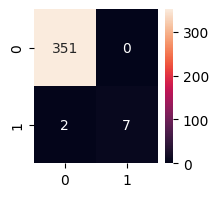

In [144]:
plt.figure(figsize=(2,2))
sb.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt= 'd')
plt.show()


In [145]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_pred,y_test)

0.9971671388101984

In [146]:
import pickle
with open("TeenDepressionAnalysisModel.pkl",'wb')as file:
    pickle.dump(best_model,file)